In [8]:
import zipfile

with zipfile.ZipFile("credit_card_fraud.csv", "r") as zip_ref:
    zip_ref.extractall("fraud_data")

# Check extracted file

import os

print(os.listdir("fraud_data"))

['creditcard.csv']


In [4]:
import pandas as pd
df = pd.read_csv("creditcard.csv")
df.head()

# Scale time and amount
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scaling 

from sklearn.preprocessing import StandardScaler

amount_scaler = StandardScaler()
time_scaler = StandardScaler()

X_train["Amount"] = amount_scaler.fit_transform(
    X_train[["Amount"]]
)

X_train["Time"] = time_scaler.fit_transform(
    X_train[["Time"]]
)

# transform test data only

X_test["Amount"] = amount_scaler.transform(
    X_test[["Amount"]]
)

X_test["Time"] = time_scaler.transform(
    X_test[["Time"]]
)

# Apply Logistics Regression

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced")

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_prob))

# thrshold tuning

y_prob = model.predict_proba(X_test)[:,1]

y_pred_new = (y_prob > 0.8).astype(int)

# again checking confusion matrix and classification report

print(classification_report(y_test, y_pred_new))
print(confusion_matrix(y_test, y_pred_new))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

[[55478  1386]
 [    8    90]]
0.9721687370080279
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.90      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962

[[56405   459]
 [   10    88]]


In [ ]:
# trying Random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(roc_auc_score(y_test, rf_prob))

# threshold tuning again 

rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_pred_new = (rf_prob > 0.3).astype(int)

print(classification_report(y_test, rf_pred_new))

print(confusion_matrix(y_test, rf_pred_new))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56861     3]
 [   25    73]]
0.952908497036969
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56857     7]
 [   17    81]]


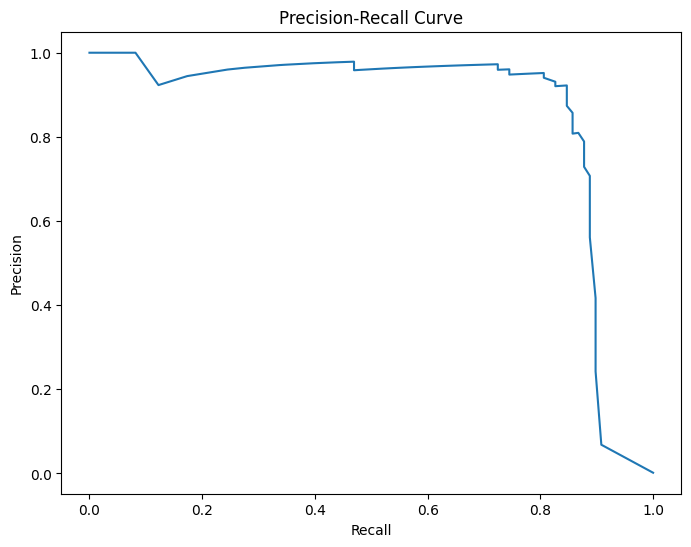

In [ ]:
# Choosing Threshold Scientifically

rf_prob = rf_model.predict_proba(X_test)[:,1]

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

# Plot curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()


In [ ]:

# Find usefull thresholds

for p, r, t in zip(precision, recall, thresholds):
    if p > 0.90 and r > 0.80:
        print(t, p, r)

0.3 0.9222222222222223 0.8469387755102041
0.32 0.9204545454545454 0.826530612244898
0.33 0.9310344827586207 0.826530612244898
0.38 0.9404761904761905 0.8061224489795918
0.41 0.9518072289156626 0.8061224489795918


In [12]:
# Random Forest Feature Importance

import pandas as pd
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)
print(importance.head(10))

   Feature  Importance
14     V14    0.179857
10     V10    0.115442
12     V12    0.096206
4       V4    0.095646
17     V17    0.095113
3       V3    0.068669
11     V11    0.056112
16     V16    0.040303
2       V2    0.036265
9       V9    0.026888


In [13]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.0 MB/s eta 0:00:51
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 1.3/101.7 MB 1.6 MB/s eta 0:01:05
    --------------------------------------- 1.6/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 1.8/101.7 MB 1.5 MB/s eta 0:01:05
   - -------------------------------------- 2.6/101.7 MB 1.7 MB/s eta 0:00:58
   - -------------------------------------- 3.1/101.7 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 3.7/101.7 MB 1.9 MB/s eta 0:00:51
   - -------------------------------------- 4.2/101.7 MB 1.9 MB/s eta 0:00:51
   - ---------

In [15]:
# Trying XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

print(roc_auc_score(y_test, xgb_prob))

# Tune Threshold
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

for t in [0.3,0.4,0.5,0.6,0.7]:
    pred = (xgb_prob > t).astype(int)

    print(t)
    print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.87      0.48        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.74     56962
weighted avg       1.00      1.00      1.00     56962

[[56695   169]
 [   13    85]]
0.981175816556223
0.3
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.17      0.89      0.29        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.64     56962
weighted avg       1.00      0.99      1.00     56962

0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.88      0.38        98

    accuracy                           1.00     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg     

In [17]:
# Hyperparameter tuning

params = {
    "max_depth": [3,4],
    "learning_rate": [0.05,0.1],
    "n_estimators": [100,200]
}

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        random_state=42
    ),
    params,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
0.9785472140792711
